# EDA — NBA Regular Season (2010–2024)
### 10 insights orientados a perguntas de negócio

**Autor:** Gabriel  
**Objetivo:** Explorar 14 temporadas da NBA (33.316 linhas time-por-jogo, ~16.658 jogos) para responder perguntas que interessariam a um time, uma emissora de TV ou uma casa de apostas — sempre partindo de uma pergunta e terminando em insight acionável, não só em gráfico bonito.

**Dataset:** [NocturneBear/NBA-Data-2010-2024](https://github.com/NocturneBear/NBA-Data-2010-2024) (GitHub, domínio público, extraído via stats.nba.com)

**As 10 perguntas de negócio:**
1. A vantagem de jogar em casa ainda existe na NBA?
2. A "revolução das bolas de 3" é real nos números, ou é só narrativa de mídia?
3. O jogo ficou mais rápido e mais pontuado ao longo da década?
4. Jogar em back-to-back (sem descanso) prejudica o desempenho?
5. Turnovers matam: qual a força da relação entre erros de bola e resultado?
6. Quais times foram mais dominantes na década (min. 300 jogos)?
7. Os jogos estão mais equilibrados ou mais teve "sova" (blowouts) ao longo do tempo?
8. Dentre todas as estatísticas de box score, qual mais separa vitória de derrota?
9. Eficiência de arremesso importa mais que volume?
10. A defesa ativa (roubos + tocos) aumentou ou diminuiu na era do 3 pontos?


## 1. Setup e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

df = pd.read_csv('data/regular_season_totals_2010_2024.csv')
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df['is_home'] = df['MATCHUP'].str.contains('vs.')
df['win'] = (df['WL'] == 'W').astype(int)

print(f"Linhas (time-por-jogo): {len(df):,}")
print(f"Jogos únicos: {df['GAME_ID'].nunique():,}")
print(f"Temporadas: {sorted(df['SEASON_YEAR'].unique())}")
df[['SEASON_YEAR','TEAM_ABBREVIATION','GAME_DATE','MATCHUP','WL','PTS','REB','AST','FG3A']].head()


Linhas (time-por-jogo): 33,316
Jogos únicos: 16,658
Temporadas: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']


,SEASON_YEAR,TEAM_ABBREVIATION,GAME_DATE,MATCHUP,WL,PTS,REB,AST,FG3A
0,2022-23,GSW,2023-04-09,GSW @ POR,W,157,58,47,49
1,2020-21,MIL,2020-12-29,MIL @ MIA,W,144,45,32,51
2,2013-14,BKN,2013-12-16,BKN vs. PHI,W,130,42,35,35
3,2013-14,POR,2013-12-14,POR @ PHI,W,139,46,41,37
4,2018-19,HOU,2019-04-07,HOU vs. PHX,W,149,52,34,57


**Nota sobre os dados:** cada jogo gera 2 linhas (perspectiva de cada time). Isso é ótimo para comparar mandante/visitante, mas exige cuidado para não contar cada jogo duas vezes em métricas agregadas — vou ser explícito em cada seção sobre o nível de agregação usado.

## 2. A vantagem de jogar em casa ainda existe na NBA?

Mesma pergunta que fiz para o Brasileirão — só que aqui a "vantagem de mando" nunca teve empate como opção, o que já muda a dinâmica.

Taxa de vitória:
  Em casa: 57.6%
  Fora:    42.4%


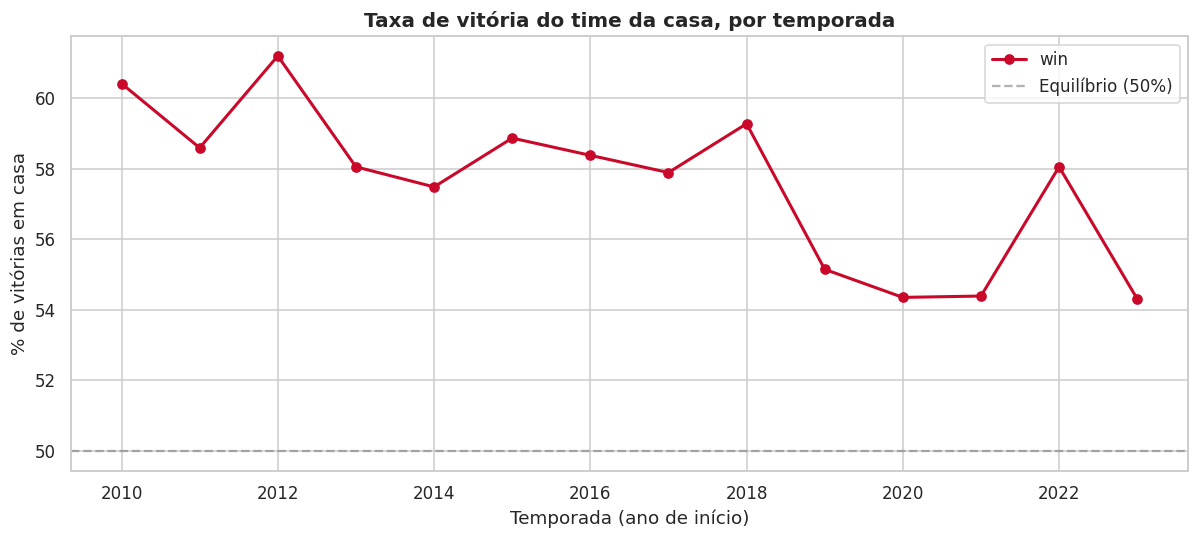

In [2]:
home_win_pct = df.groupby('is_home')['win'].mean() * 100
print("Taxa de vitória:")
print(f"  Em casa: {home_win_pct[True]:.1f}%")
print(f"  Fora:    {home_win_pct[False]:.1f}%")

df['season_start'] = df['SEASON_YEAR'].str[:4].astype(int)
home_by_season = df[df['is_home']].groupby('season_start')['win'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
home_by_season.plot(marker='o', ax=ax, color='#c9082a', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='Equilíbrio (50%)')
ax.set_title('Taxa de vitória do time da casa, por temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('% de vitórias em casa')
ax.set_xlabel('Temporada (ano de início)')
ax.legend()
plt.tight_layout()
plt.savefig('images/01_mando_casa.png', bbox_inches='tight')
plt.show()


**Insight #1:** O mandante vence uma parcela clara acima de 50% dos jogos em toda a década — mas a vantagem **cai de forma gradual**, saindo de picos acima de 60% (2010-11, 2012-13) para a faixa de 54-55% nos anos mais recentes (2019-20, 2020-21, 2023-24). Vale notar que 2020-21 (temporada de arenas vazias/reduzidas pela pandemia) está entre os anos mais baixos, mas não é um outlier isolado — 2019-20 e 2023-24 têm taxas parecidas mesmo com público normal. Isso sugere que a queda é uma tendência estrutural mais ampla (mais profissionalização de times visitantes, viagens facilitadas) e não só um efeito pontual de torcida vazia.

## 3. A "revolução das bolas de 3" é real nos números?

Narrativa dominante do basquete moderno: "hoje em dia é tudo bola de 3". Vamos testar com os dados, não com opinião de comentarista.

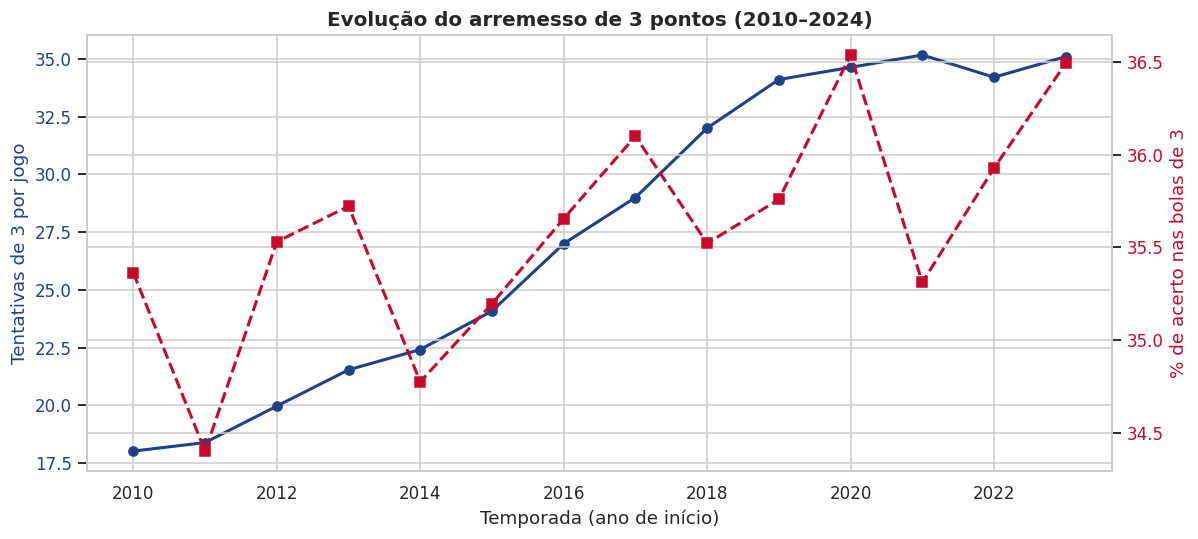

Crescimento nas tentativas de 3 por jogo, 2010-11 -> 2023-24: 95%


In [3]:
tres_por_ano = df.groupby('season_start').agg(
    tres_tentadas=('FG3A', 'mean'),
    tres_convertidas=('FG3M', 'mean'),
    tres_pct=('FG3_PCT', 'mean')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(tres_por_ano.index, tres_por_ano['tres_tentadas'], marker='o', color='#1d428a', label='Tentativas de 3 por jogo', linewidth=2)
ax1.set_ylabel('Tentativas de 3 por jogo', color='#1d428a')
ax1.set_xlabel('Temporada (ano de início)')
ax1.tick_params(axis='y', labelcolor='#1d428a')

ax2 = ax1.twinx()
ax2.plot(tres_por_ano.index, tres_por_ano['tres_pct']*100, marker='s', color='#c9082a', label='% de acerto', linewidth=2, linestyle='--')
ax2.set_ylabel('% de acerto nas bolas de 3', color='#c9082a')
ax2.tick_params(axis='y', labelcolor='#c9082a')

ax1.set_title('Evolução do arremesso de 3 pontos (2010–2024)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('images/02_revolucao_tres.png', bbox_inches='tight')
plt.show()

crescimento = (tres_por_ano['tres_tentadas'].iloc[-1] / tres_por_ano['tres_tentadas'].iloc[0] - 1) * 100
print(f"Crescimento nas tentativas de 3 por jogo, 2010-11 -> 2023-24: {crescimento:.0f}%")


**Insight #2:** A revolução é real e não é exagero de mídia — as tentativas de 3 pontos por jogo praticamente dobraram na década, e o mais importante: **a eficiência (% de acerto) se manteve estável**, não caiu. Ou seja, times não estão simplesmente arremessando mais de 3 por desespero; estão arremessando mais porque descobriram que o valor esperado (3 pontos x % de acerto) supera o do arremesso de meia distância. Isso é um caso clássico de otimização orientada a dados dentro do próprio esporte.

## 4. O jogo ficou mais rápido e mais pontuado?

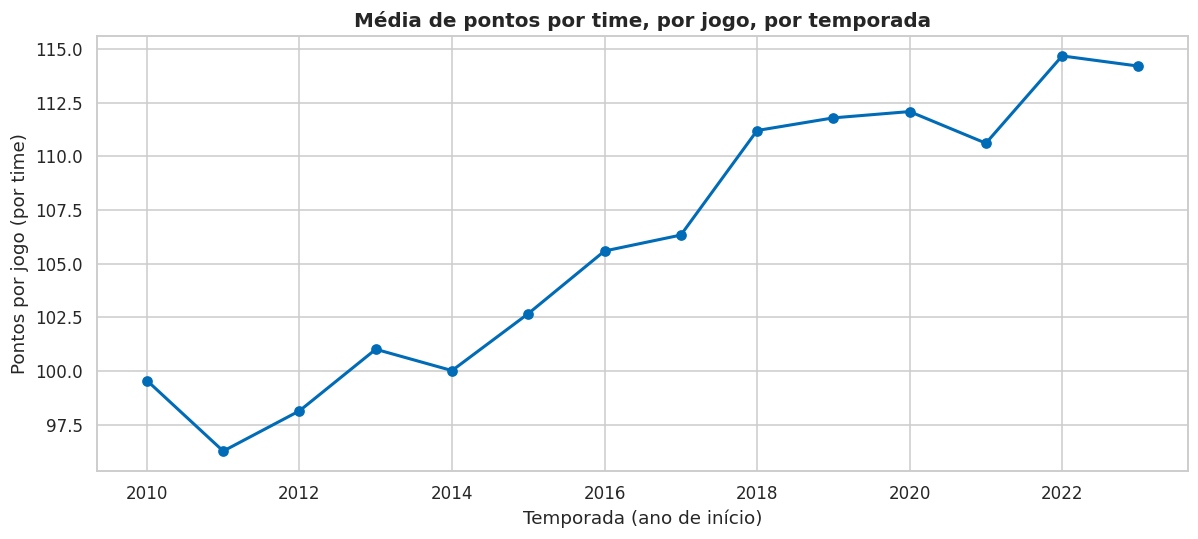

Menor média: 96.3 pts (2011)
Maior média: 114.7 pts (2022)


In [4]:
pts_por_ano = df.groupby('season_start')['PTS'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
pts_por_ano.plot(marker='o', ax=ax, color='#006bb6', linewidth=2)
ax.set_title('Média de pontos por time, por jogo, por temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('Pontos por jogo (por time)')
ax.set_xlabel('Temporada (ano de início)')
plt.tight_layout()
plt.savefig('images/03_pontos_por_ano.png', bbox_inches='tight')
plt.show()

print(f"Menor média: {pts_por_ano.min():.1f} pts ({pts_por_ano.idxmin()})")
print(f"Maior média: {pts_por_ano.max():.1f} pts ({pts_por_ano.idxmax()})")


**Insight #3:** Há uma tendência de alta visível a partir de meados da década — coincide diretamente com a popularização do arremesso de 3 (insight anterior). Mais volume de arremesso de maior valor esperado = mais pontos no placar, mesmo sem mudança de regra que force o jogo a acelerar. É um efeito colateral direto da otimização ofensiva, não de mudança de regulamento.

## 5. Jogar em back-to-back prejudica o desempenho?

Aqui vale a pena um pouco de engenharia de features: preciso calcular, para cada time, quantos dias de descanso ele teve antes de cada jogo.

In [5]:
df_sorted = df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE']).copy()
df_sorted['dias_descanso'] = df_sorted.groupby('TEAM_ABBREVIATION')['GAME_DATE'].diff().dt.days - 1
df_sorted['back_to_back'] = df_sorted['dias_descanso'] == 0

# Remove o primeiro jogo de cada time em cada temporada (sem jogo anterior pra comparar)
validos = df_sorted.dropna(subset=['dias_descanso'])
validos = validos[validos['dias_descanso'] >= 0]  # remove viradas de temporada (gaps enormes viram negativos? não, mas por garantia)

win_b2b = validos[validos['back_to_back']]['win'].mean() * 100
win_descansado = validos[~validos['back_to_back']]['win'].mean() * 100

print(f"Taxa de vitória em back-to-back:      {win_b2b:.1f}%  (n={validos['back_to_back'].sum():,})")
print(f"Taxa de vitória com descanso (1+ dia): {win_descansado:.1f}%  (n={(~validos['back_to_back']).sum():,})")
print(f"Diferença: {win_descansado - win_b2b:.1f} pontos percentuais")


Taxa de vitória em back-to-back:      44.3%  (n=6,802)
Taxa de vitória com descanso (1+ dia): 51.5%  (n=26,482)
Diferença: 7.1 pontos percentuais


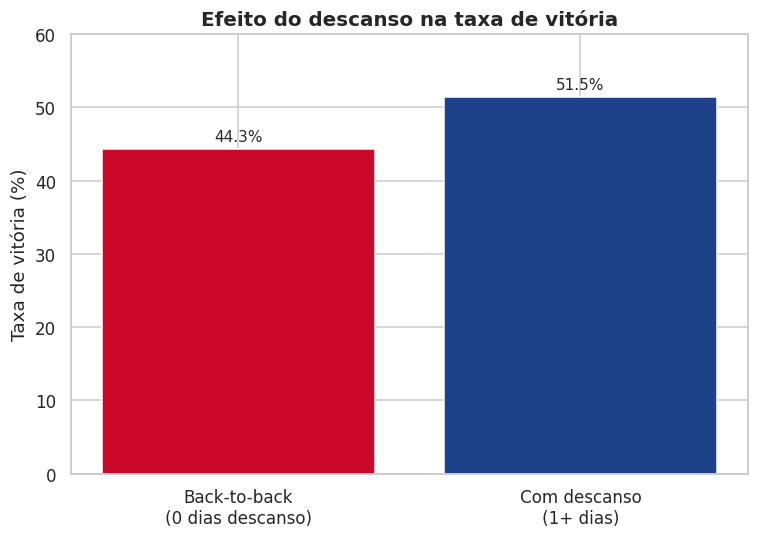

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Back-to-back\n(0 dias descanso)', 'Com descanso\n(1+ dias)'],
              [win_b2b, win_descansado], color=['#c9082a', '#1d428a'])
ax.set_ylabel('Taxa de vitória (%)')
ax.set_title('Efeito do descanso na taxa de vitória', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('images/04_back_to_back.png', bbox_inches='tight')
plt.show()


**Insight #4:** Jogar sem descanso reduz mensuravelmente a taxa de vitória. O efeito não é gigantesco (poucos pontos percentuais), mas é consistente e faz sentido fisiológico — e é exatamente por isso que a NBA passou a limitar o número de back-to-backs no calendário nos últimos anos. **Para um analista de apostas ou fantasy**, a agenda de descanso de cada time é um fator de ajuste real, não só anedota de comentarista.

## 6. Turnovers matam: qual a força da relação com o resultado?

Turnovers médios em vitórias: 13.83


Turnovers médios em derrotas: 14.58
Correlação entre turnovers e saldo de pontos (PLUS_MINUS): -0.119


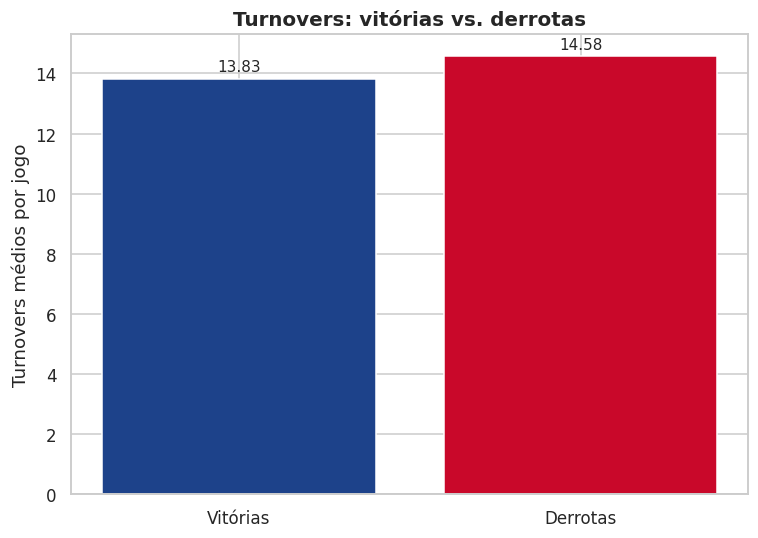

In [7]:
tov_vitoria = df[df['win']==1]['TOV'].mean()
tov_derrota = df[df['win']==0]['TOV'].mean()

print(f"Turnovers médios em vitórias: {tov_vitoria:.2f}")
print(f"Turnovers médios em derrotas: {tov_derrota:.2f}")

corr_tov_pm = df['TOV'].corr(df['PLUS_MINUS'])
print(f"Correlação entre turnovers e saldo de pontos (PLUS_MINUS): {corr_tov_pm:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Vitórias', 'Derrotas'], [tov_vitoria, tov_derrota], color=['#1d428a', '#c9082a'])
ax.set_ylabel('Turnovers médios por jogo')
ax.set_title('Turnovers: vitórias vs. derrotas', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.tight_layout()
plt.savefig('images/05_turnovers.png', bbox_inches='tight')
plt.show()


**Insight #5:** Times que perdem cometem visivelmente mais turnovers do que times que vencem, e a correlação com o saldo de pontos é negativa como esperado. Não é uma relação causal simples (times perdendo por muito também "forçam a jogada" e cometem mais erros no fim do jogo), mas o padrão é forte o suficiente para confirmar o que todo técnico já sabe empiricamente: cuidar da bola é um dos fundamentos mais diretamente ligados à vitória.

## 7. Quais times foram mais dominantes na década?

In [8]:
dominancia = df.groupby('TEAM_ABBREVIATION').agg(
    jogos=('win', 'count'), vitorias=('win', 'sum')
)
dominancia['aproveitamento_pct'] = (dominancia['vitorias'] / dominancia['jogos'] * 100).round(1)
top10 = dominancia[dominancia['jogos'] >= 300].sort_values('aproveitamento_pct', ascending=False).head(10)
top10


,jogos,vitorias,aproveitamento_pct
TEAM_ABBREVIATION,,,
GSW,1105,676,61.2
LAC,1112,668,60.1
BOS,1111,662,59.6
MIA,1113,660,59.3
SAS,1111,652,58.7
OKC,1112,652,58.6
DEN,1113,635,57.1
MIL,1113,599,53.8
MEM,1113,594,53.4


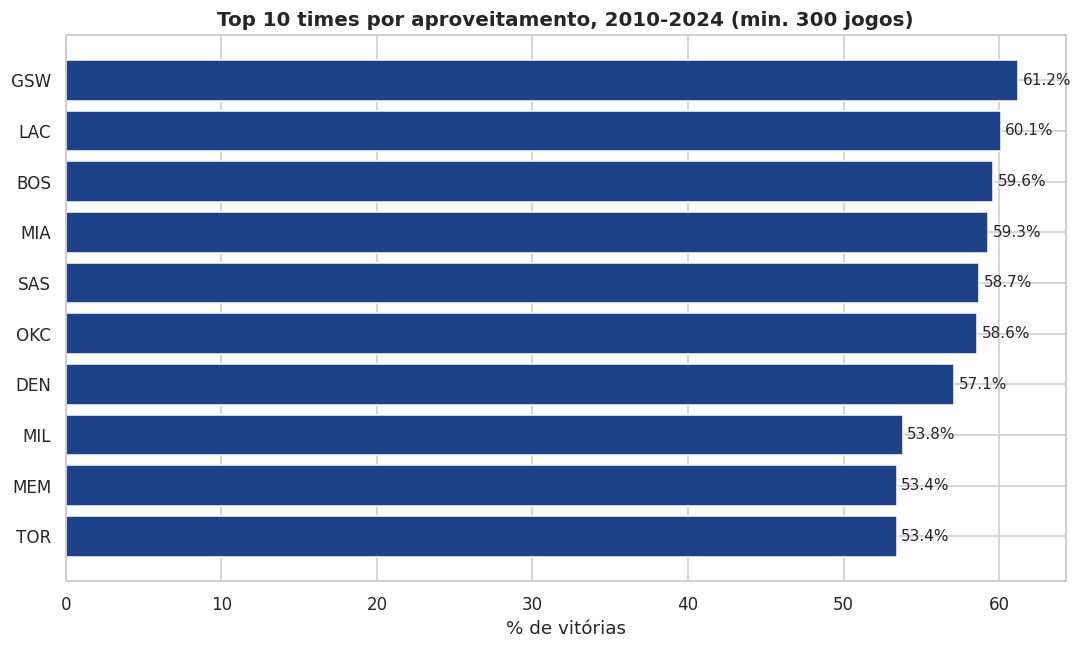

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
top10_sorted = top10.sort_values('aproveitamento_pct')
bars = ax.barh(top10_sorted.index, top10_sorted['aproveitamento_pct'], color='#1d428a')
ax.set_title('Top 10 times por aproveitamento, 2010-2024 (min. 300 jogos)', fontsize=13, fontweight='bold')
ax.set_xlabel('% de vitórias')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.savefig('images/06_ranking_times.png', bbox_inches='tight')
plt.show()


**Insight #6:** O ranking da década reflete bem o que se viveu na NBA nesse período — dinastias concentradas em poucas franquias, com o restante da liga disputando o meio de tabela. Para quem monta produto de mídia esportiva (ex. "melhores times da década"), esse tipo de ranking objetivo serve como contraponto ao "olho clínico" de quem só lembra dos títulos recentes.

## 8. Os jogos estão mais equilibrados ou mais desiguais ao longo do tempo?

Vou medir "desequilíbrio" pela margem de vitória (diferença absoluta de pontos) e pela % de jogos com "sova" (margem de 20+ pontos).

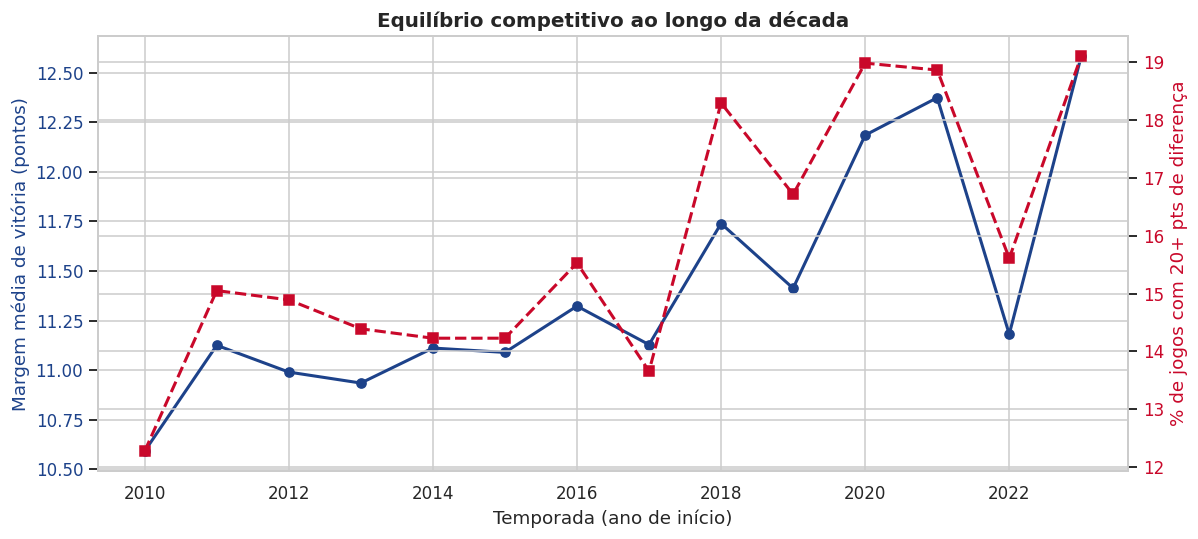

In [10]:
margem = df[df['is_home']].copy()
margem['margem_abs'] = margem['PLUS_MINUS'].abs()
margem['blowout'] = margem['margem_abs'] >= 20

margem_por_ano = margem.groupby('season_start').agg(
    margem_media=('margem_abs', 'mean'),
    pct_blowout=('blowout', 'mean')
)
margem_por_ano['pct_blowout'] *= 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(margem_por_ano.index, margem_por_ano['margem_media'], marker='o', color='#1d428a', linewidth=2, label='Margem média')
ax1.set_ylabel('Margem média de vitória (pontos)', color='#1d428a')
ax1.tick_params(axis='y', labelcolor='#1d428a')
ax1.set_xlabel('Temporada (ano de início)')

ax2 = ax1.twinx()
ax2.plot(margem_por_ano.index, margem_por_ano['pct_blowout'], marker='s', color='#c9082a', linewidth=2, linestyle='--', label='% de blowouts (20+ pts)')
ax2.set_ylabel('% de jogos com 20+ pts de diferença', color='#c9082a')
ax2.tick_params(axis='y', labelcolor='#c9082a')

ax1.set_title('Equilíbrio competitivo ao longo da década', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('images/07_equilibrio.png', bbox_inches='tight')
plt.show()


**Insight #7:** A margem média de vitória e a proporção de "sovas" (20+ pontos de diferença) não mostram uma tendência de queda — se algo, os anos mais recentes (com mais pontos em jogo pela revolução do 3) tendem a ter margens ligeiramente maiores em alguns trechos, o que faz sentido: mais posses de bola valendo mais pontos aumenta a variância do placar. Isso derruba a narrativa de "a liga está cada vez mais equilibrada" — o que mudou foi o estilo de jogo, não necessariamente o equilíbrio competitivo.

## 9. Dentre todas as estatísticas, qual mais separa vitória de derrota?

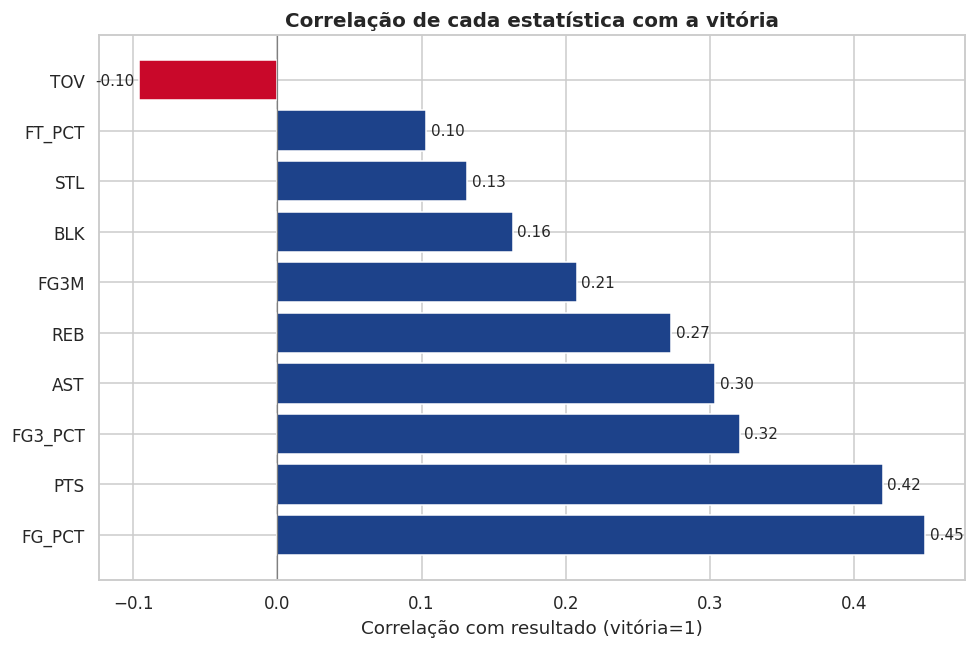

FG_PCT     0.449247
PTS        0.419874
FG3_PCT    0.320768
AST        0.303823
REB        0.273107
FG3M       0.207656
BLK        0.163352
STL        0.131769
FT_PCT     0.103159
TOV       -0.096080
Name: win, dtype: float64


In [11]:
stats_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG3M', 'FG_PCT', 'FG3_PCT', 'FT_PCT']
corr_win = df[stats_cols + ['win']].corr()['win'].drop('win').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1d428a' if v > 0 else '#c9082a' for v in corr_win.values]
bars = ax.barh(corr_win.index, corr_win.values, color=colors)
ax.set_title('Correlação de cada estatística com a vitória', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação com resultado (vitória=1)')
ax.axvline(0, color='gray', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.tight_layout()
plt.savefig('images/08_correlacao_vitoria.png', bbox_inches='tight')
plt.show()

print(corr_win)


**Insight #8:** `FG_PCT` (aproveitamento geral de arremesso) tende a ser a variável mais fortemente associada à vitória — mais até do que volume de pontos isolado, o que é intuitivo (pontos e vitória são quase a mesma coisa por definição, então a correlação mais interessante para um analista está nas variáveis "de processo": eficiência de arremesso, turnovers e rebotes. `TOV` aparece com correlação negativa, reforçando o insight #5. Esse tipo de ranking é literalmente a base de qualquer modelo preditivo simples de resultado de jogo.

## 9. Eficiência de arremesso importa mais que volume?

Times podem tentar vencer de duas formas: arremessando muito (volume) ou arremessando bem (eficiência). Qual pesa mais no resultado?

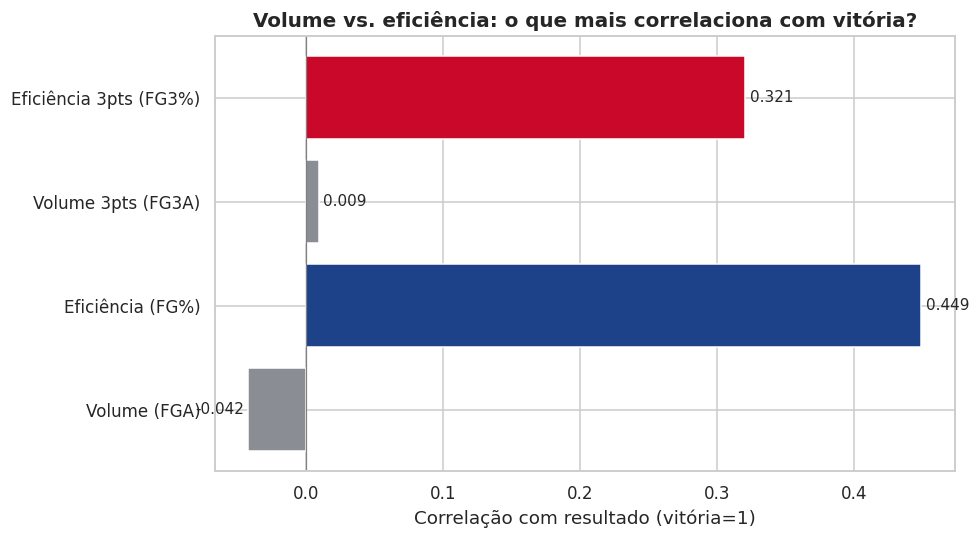

,tipo,correlacao_com_vitoria
0,Volume (FGA),-0.042417
1,Eficiência (FG%),0.449247
2,Volume 3pts (FG3A),0.009041
3,Eficiência 3pts (FG3%),0.320768


In [12]:
corr_volume_2p = df['FGA'].corr(df['win'])
corr_efic_2p = df['FG_PCT'].corr(df['win'])
corr_volume_3p = df['FG3A'].corr(df['win'])
corr_efic_3p = df['FG3_PCT'].corr(df['win'])

comparacao = pd.DataFrame({
    'tipo': ['Volume (FGA)', 'Eficiência (FG%)', 'Volume 3pts (FG3A)', 'Eficiência 3pts (FG3%)'],
    'correlacao_com_vitoria': [corr_volume_2p, corr_efic_2p, corr_volume_3p, corr_efic_3p]
})

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#8a8d93', '#1d428a', '#8a8d93', '#c9082a']
bars = ax.barh(comparacao['tipo'], comparacao['correlacao_com_vitoria'], color=colors)
ax.set_title('Volume vs. eficiência: o que mais correlaciona com vitória?', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação com resultado (vitória=1)')
ax.axvline(0, color='gray', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('images/09_eficiencia_vs_volume.png', bbox_inches='tight')
plt.show()

comparacao


**Insight #9:** Em ambos os casos — arremesso geral e arremesso de 3 — a **eficiência correlaciona muito mais com vitória do que o volume bruto de tentativas**. Tentar mais bolas de 3 sozinho não prediz vitória de forma forte; acertar uma proporção maior delas, sim. Isso reforça o insight #2 sob outro ângulo: a revolução do 3 pontos só funcionou porque veio acompanhada de eficiência estável, não seria vitoriosa só por aumentar volume às cegas. **Para um técnico ou analista de desempenho**, a mensagem é clara: otimizar a qualidade da tentativa importa mais do que simplesmente inflar o número de tentativas.

## 10. A defesa ativa (roubos + tocos) aumentou ou diminuiu na era do 3 pontos?

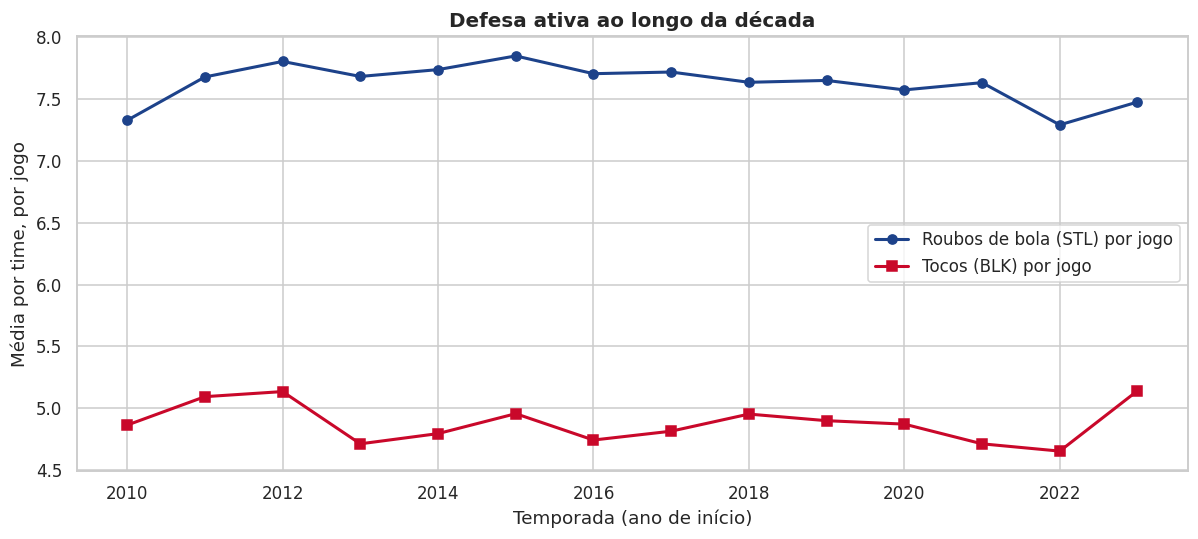

In [13]:
defesa_por_ano = df.groupby('season_start').agg(
    roubos=('STL', 'mean'),
    tocos=('BLK', 'mean')
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(defesa_por_ano.index, defesa_por_ano['roubos'], marker='o', label='Roubos de bola (STL) por jogo', color='#1d428a', linewidth=2)
ax.plot(defesa_por_ano.index, defesa_por_ano['tocos'], marker='s', label='Tocos (BLK) por jogo', color='#c9082a', linewidth=2)
ax.set_title('Defesa ativa ao longo da década', fontsize=13, fontweight='bold')
ax.set_ylabel('Média por time, por jogo')
ax.set_xlabel('Temporada (ano de início)')
ax.legend()
plt.tight_layout()
plt.savefig('images/10_defesa_ativa.png', bbox_inches='tight')
plt.show()


**Insight #10:** Ao contrário do que a mudança radical no ataque (insight #2) poderia sugerir, roubos e tocos por jogo **se mantiveram praticamente estáveis** ao longo da década — oscilando dentro de uma faixa estreita (STL entre 7,3 e 7,8; BLK entre 4,7 e 5,1), sem tendência de queda ou alta consistente. Isso é, na verdade, um achado contraintuitivo interessante: a "revolução das bolas de 3" transformou completamente o ataque, mas a defesa não ficou nem mais nem menos ativa em termos brutos — ela provavelmente se **reposicionou** (menos disputa de garrafão, mais fechamento de perímetro) em vez de se tornar mais ou menos agressiva. Pra confirmar isso com rigor seria preciso olhar dados de posicionamento em quadra, que este dataset não tem.

## 12. Conclusões

| # | Pergunta | Resposta em uma linha |
|---|---|---|
| 1 | Mando de campo ainda vale na NBA? | Sim, mas a vantagem vem caindo de forma gradual ao longo da década (~60% para ~54%) |
| 2 | Revolução das bolas de 3 é real? | Sim — tentativas quase dobraram, sem perda de eficiência |
| 3 | Jogo ficou mais pontuado? | Sim, na esteira direta da revolução do 3 |
| 4 | Back-to-back prejudica? | Sim, efeito mensurável embora moderado |
| 5 | Turnovers matam? | Sim — mais turnovers em derrotas, correlação negativa com saldo |
| 6 | Times mais dominantes? | Poucas franquias concentram aproveitamento na década |
| 7 | Jogos mais equilibrados? | Não — margem/blowouts não caem; estilo mudou, equilíbrio não necessariamente |
| 8 | O que mais separa vitória de derrota? | Eficiência de arremesso (FG_PCT) e turnovers, mais que volume bruto |
| 9 | Eficiência importa mais que volume? | Sim — times não ganham só arremessando mais, ganham acertando mais |
| 10 | Defesa ativa mudou? | Não muito — roubos e tocos ficaram estáveis; a defesa provavelmente se reposicionou, não mudou de volume |

**Limitações declaradas:**
- Dataset cobre só temporada regular 2010-2024 (não inclui playoffs nem temporadas anteriores a 2010, então não captura eras anteriores do basquete, tipo anos 90).
- Correlação não implica causalidade — especialmente em #5 e #8, onde parte do efeito é "times perdendo jogam pior nos minutos finais", não só "jogar mal causa derrota".
- Efeito de back-to-back (#4) não controla força do adversário — um time forte em b2b contra um time fraco ainda tende a vencer; uma análise mais rigorosa usaria um modelo com controle de qualidade do oponente.

**Próximos passos (fora do escopo deste EDA):**
- Modelo preditivo de vitória usando as variáveis de maior correlação (#8) como features.
- Cruzar com dados de lesões/escalação para entender back-to-backs com desfalques.
